# Campus Placement — ML Project
# Baseline Models 

This notebook trains two baseline classifiers on the preprocessed placement data.
The goal here is to establish a performance floor before moving to relatively more complex models.

**Models trained:**
- Logistic Regression — linear, interpretable, standard first-pass classifier
- Decision Tree — non-linear, rule-based, naturally interpretable via the visualisation

**Evaluation metrics used:**
- Weighted F1-score (primary) to account for class imbalance (the 2.2:1 ratio)
- Accuracy is reported but treated as secondary given the imbalance
- Precision and recall per class is for understanding the `Not Placed` performances
- Confusion matrix to show exactly where each model makes mistakes

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


---
## 2. Load preprocessed data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

CLASS_NAMES = ['Not Placed', 'Placed']
FEATURE_NAMES = X_train.columns.tolist()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {FEATURE_NAMES}')

X_train: (172, 12)  |  X_test: (43, 12)
Features: ['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p']


---
## 3. Helper function to evaluate and display any classifier

Rather than repeating evaluation code for every model, I've used a reusable function which hopefully kepss the notebook tidy.

In [3]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    """
    Trains model, prints classification report, plots confusion matrix.
    Returns a results dict for later comparison.
    """
    # --- Train ---
    model.fit(X_tr, y_tr)

    # --- Predictions on both sets ---
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # --- Metrics ---
    train_acc = accuracy_score(y_tr, y_pred_train)
    test_acc  = accuracy_score(y_te, y_pred_test)
    train_f1  = f1_score(y_tr, y_pred_train, average='weighted')
    test_f1   = f1_score(y_te, y_pred_test,  average='weighted')
    overfit_gap = train_f1 - test_f1

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Train accuracy : {train_acc:.3f}   Train F1 (weighted): {train_f1:.3f}')
    print(f'  Test  accuracy : {test_acc:.3f}   Test  F1 (weighted): {test_f1:.3f}')
    print(f'  Overfit gap (train F1 - test F1): {overfit_gap:.3f}')
    if overfit_gap > 0.10:
        print('  WARNING: gap > 0.10 — model may be overfitting')
    print()

    # --- Full classification report (test set) ---
    print('Classification report (test set):')
    print(classification_report(y_te, y_pred_test,
                                target_names=CLASS_NAMES, digits=3))

    # --- Confusion matrix ---
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    cm = confusion_matrix(y_te, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — confusion matrix (test set)', fontsize=12)
    plt.tight_layout()
    plt.show()

    return {
        'model':      model,
        'name':       model_name,
        'train_acc':  train_acc,
        'test_acc':   test_acc,
        'train_f1':   train_f1,
        'test_f1':    test_f1,
        'y_pred':     y_pred_test
    }

print('evaluate_model() defined.')

evaluate_model() defined.


---
## 4. Baseline Model A — Logistic Regression

Logistic Regression is the standard first baseline for binary classification since it models the log-odds of the positive class as a linear combination of features making it fast, interpretable via coefficients and well-suited to a dataset of this size.

`class_weight='balanced'` is used to address the 2.2:1 class imbalance which internally upweights the minority class (`Not Placed`) during training so the model does not simply learn to always predict the majority class.


  Logistic Regression (baseline)
  Train accuracy : 0.895   Train F1 (weighted): 0.897
  Test  accuracy : 0.860   Test  F1 (weighted): 0.865
  Overfit gap (train F1 - test F1): 0.032

Classification report (test set):
              precision    recall  f1-score   support

  Not Placed      0.706     0.923     0.800        13
      Placed      0.962     0.833     0.893        30

    accuracy                          0.860        43
   macro avg      0.834     0.878     0.846        43
weighted avg      0.884     0.860     0.865        43



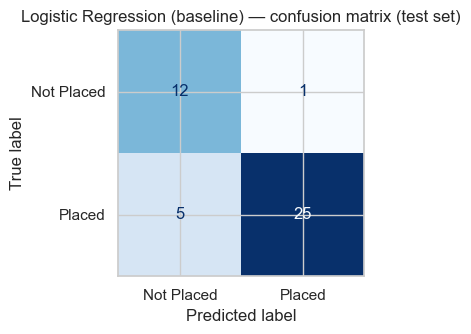

In [4]:
lr_model = LogisticRegression(
    max_iter=1000,          # increase from default 100 to ensure convergence
    class_weight='balanced',# compensate for 2.2:1 class imbalance
    random_state=SEED
)

lr_results = evaluate_model(
    lr_model, X_train, y_train, X_test, y_test,
    model_name='Logistic Regression (baseline)'
)

### 4a. Logistic Regression — coefficient plot

Coefficients show the direction and magnitude of each feature's influence on
the log-odds of placement. 

- Positive = increases probability of `Placed`
- Negative = decreases it, an interpretability advantages of logistic regression over tree models

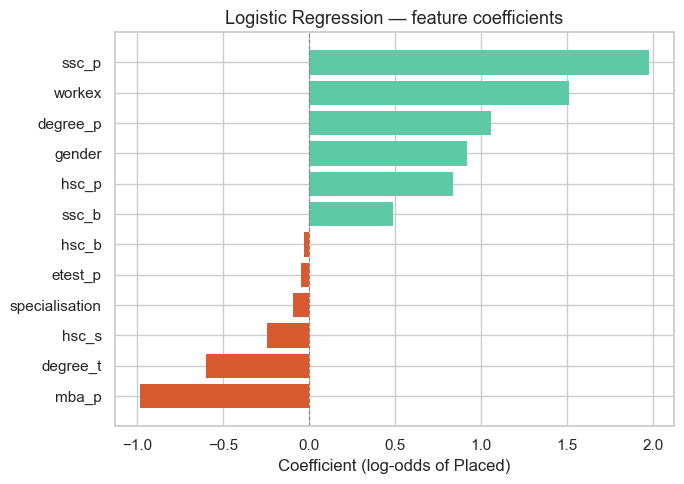

Top 3 features increasing placement probability:
 feature  coefficient
degree_p     1.054046
  workex     1.507757
   ssc_p     1.972531

Top 3 features decreasing placement probability:
 feature  coefficient
   mba_p    -0.979544
degree_t    -0.596576
   hsc_s    -0.242215


In [5]:
coef_df = pd.DataFrame({
    'feature':     FEATURE_NAMES,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient')

colors = ['#D85A30' if c < 0 else '#5DCAA5' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='none')
ax.axvline(0, color='#888780', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — feature coefficients', fontsize=13)
ax.set_xlabel('Coefficient (log-odds of Placed)')
plt.tight_layout()
plt.show()

print('Top 3 features increasing placement probability:')
print(coef_df.tail(3)[['feature','coefficient']].to_string(index=False))
print('\nTop 3 features decreasing placement probability:')
print(coef_df.head(3)[['feature','coefficient']].to_string(index=False))

---
## 5. Baseline Model B — Decision Tree

A Decision Tree partitions the feature space using a series of binary rules learned from the training data. 

I've used a `max_depth=4` constraint to prevent overfitting as an unconstrained tree on 172 training rows will memorise the data (train F1 = 1.0) while performing poorly on unseen examples.


  Decision Tree (depth=4, baseline)
  Train accuracy : 0.866   Train F1 (weighted): 0.871
  Test  accuracy : 0.744   Test  F1 (weighted): 0.754
  Overfit gap (train F1 - test F1): 0.116

Classification report (test set):
              precision    recall  f1-score   support

  Not Placed      0.550     0.846     0.667        13
      Placed      0.913     0.700     0.792        30

    accuracy                          0.744        43
   macro avg      0.732     0.773     0.730        43
weighted avg      0.803     0.744     0.754        43



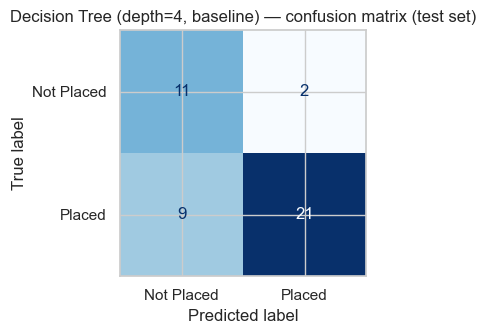

In [6]:
dt_model = DecisionTreeClassifier(
    max_depth=4,             # prevent overfitting
    class_weight='balanced', # same imbalance correction as LR
    random_state=SEED
)

dt_results = evaluate_model(
    dt_model, X_train, y_train, X_test, y_test,
    model_name='Decision Tree (depth=4, baseline)'
)

### 5a. Decision Tree — visualisation

Each node shows: the split condition, the Gini impurity, the sample count, and the class distribution.

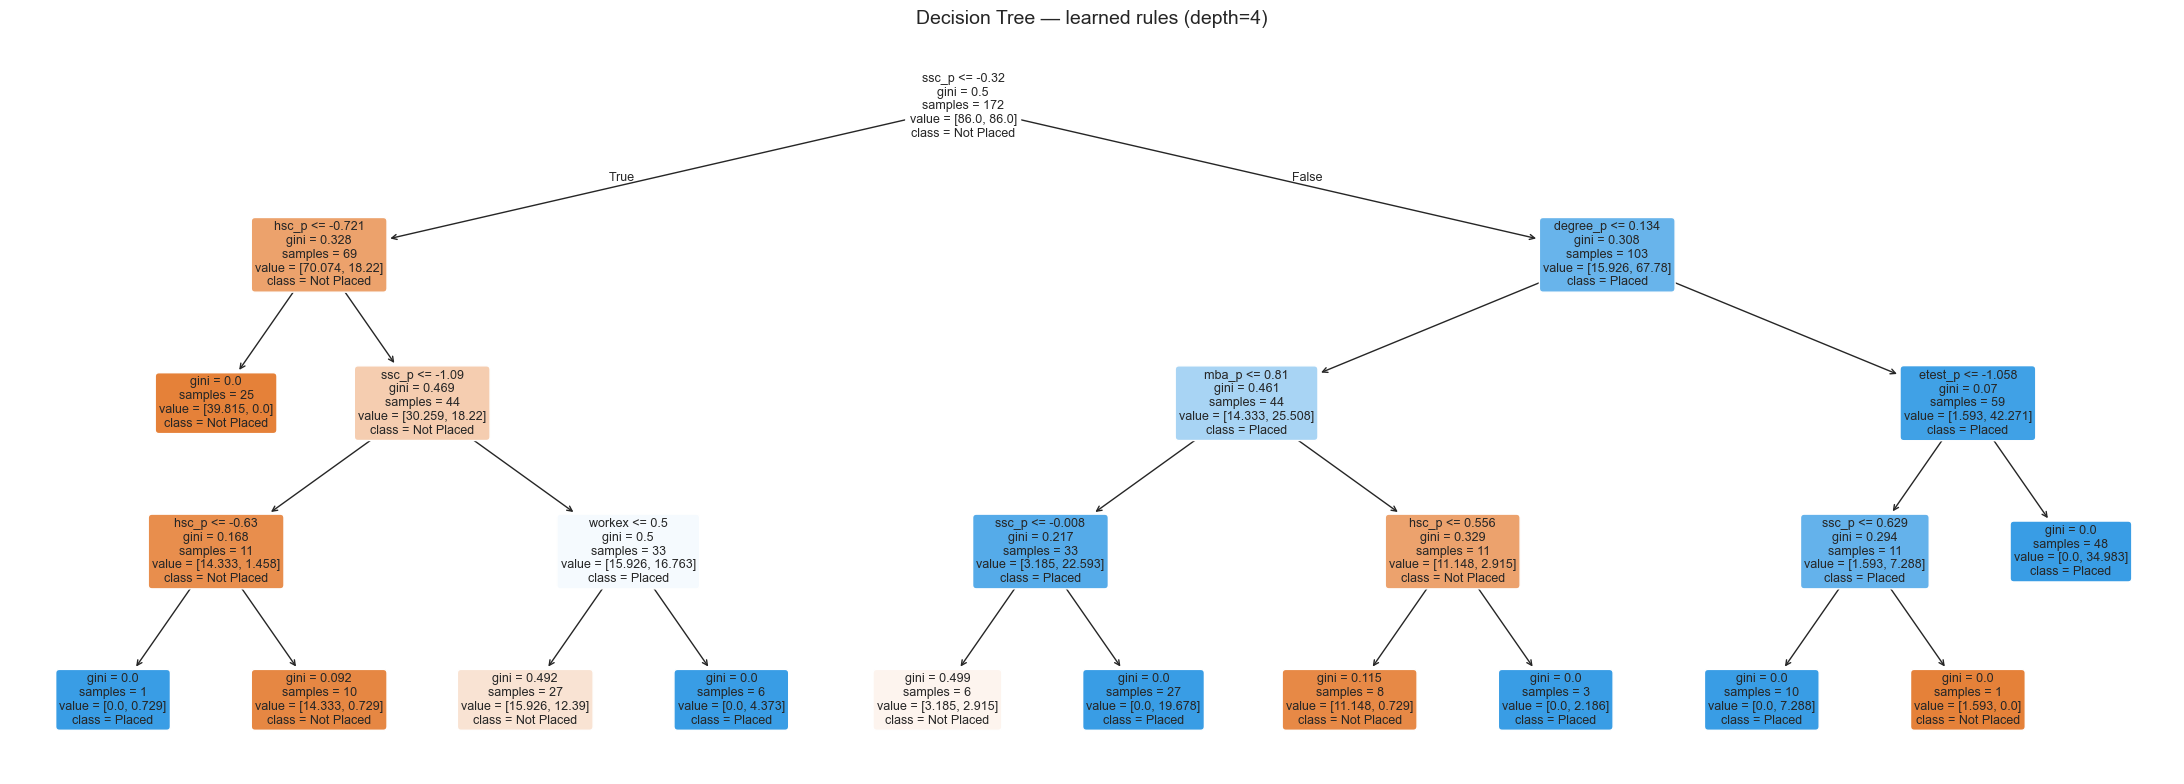

In [7]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Decision Tree — learned rules (depth=4)', fontsize=14)
plt.tight_layout()
plt.show()

**Brief Summary**
The tree makes its first split on ssc_p <= -0.32 (secondary school score, standardised). Students below this threshold (left branch, 69 of 172) are already majority Not Placed and low secondary school performance is the single strongest early signal of non-placement. Within this group, a further split on hsc_p separates the lowest performers (25 students, gini=0.0, pure Not Placed leaf) from borderline cases where workex becomes the deciding factor where students with work experience (workex <= 0.5 = False, i.e. Yes) are more likely to be placed despite weaker academic scores.

The right branch (103 students, ssc_p > -0.32) represents higher-scoring students who are predominantly Placed. Here the tree splits on degree_p and then etest_p, with the rightmost branch (59 students) resolved almost entirely by employability test score. The tree therefore encodes a sensible academic progression logic by which secondary score sets the broad filter, then degree score and employability test refine predictions for students in the middle range. The pure leaf nodes (gini=0.0) indicate groups where the model is completely certain and these are the cleanest decision boundaries in the data.

### 5b. Decision Tree — overfitting check across depths

`max_depth` from 1 to 10 is used to plot both training and test F1.

The point where train F1 keeps rising but test F1 plateaus or drops is where overfitting begins which justifies the choice of `max_depth=4`.

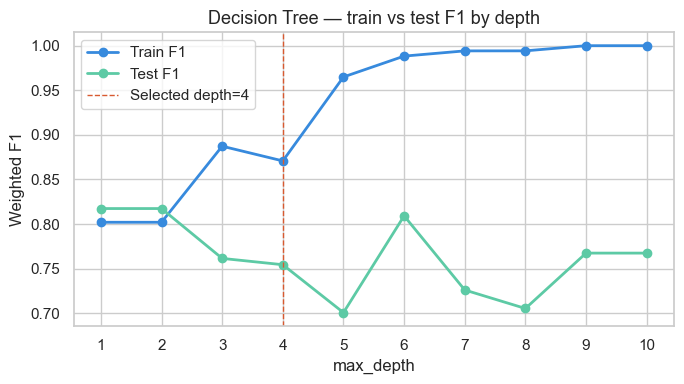

Best test F1 at depth 1: 0.817


In [8]:
depths      = range(1, 11)
train_f1s   = []
test_f1s    = []

for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d, class_weight='balanced', random_state=SEED
    )
    dt.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, dt.predict(X_train), average='weighted'))
    test_f1s.append( f1_score(y_test,  dt.predict(X_test),  average='weighted'))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_f1s, marker='o', label='Train F1', color='#378ADD', linewidth=2)
ax.plot(depths, test_f1s,  marker='o', label='Test F1',  color='#5DCAA5', linewidth=2)
ax.axvline(4, color='#D85A30', linestyle='--', linewidth=1, label='Selected depth=4')
ax.set_xlabel('max_depth')
ax.set_ylabel('Weighted F1')
ax.set_title('Decision Tree — train vs test F1 by depth', fontsize=13)
ax.legend()
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_f1s)]
print(f'Best test F1 at depth {best_depth}: {max(test_f1s):.3f}')

---
## 6. A side-by-side baseline comparison

=== Baseline Model Comparison ===
                            Model  Train Acc  Test Acc  Train F1  Test F1  Overfit Gap
   Logistic Regression (baseline)      0.895     0.860     0.897    0.865        0.032
Decision Tree (depth=4, baseline)      0.866     0.744     0.871    0.754        0.116


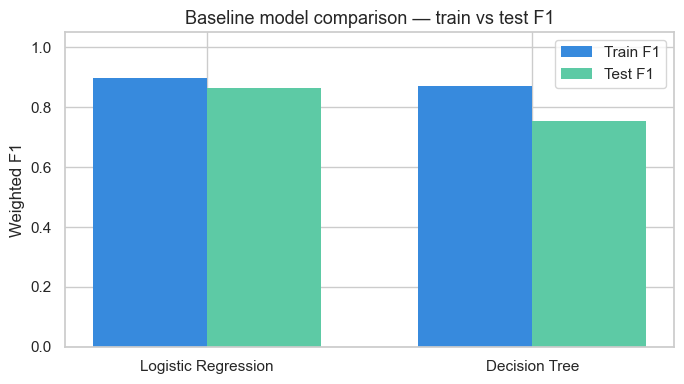

In [9]:
results_list = [lr_results, dt_results]

comparison = pd.DataFrame([{
    'Model':        r['name'],
    'Train Acc':    round(r['train_acc'], 3),
    'Test Acc':     round(r['test_acc'],  3),
    'Train F1':     round(r['train_f1'],  3),
    'Test F1':      round(r['test_f1'],   3),
    'Overfit Gap':  round(r['train_f1'] - r['test_f1'], 3)
} for r in results_list])

print('=== Baseline Model Comparison ===')
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x     = np.arange(len(results_list))
width = 0.35
names = [r['name'].split('(')[0].strip() for r in results_list]

ax.bar(x - width/2, comparison['Train F1'], width, label='Train F1',
       color='#378ADD', edgecolor='none')
ax.bar(x + width/2, comparison['Test F1'],  width, label='Test F1',
       color='#5DCAA5', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Weighted F1')
ax.set_ylim(0, 1.05)
ax.set_title('Baseline model comparison — train vs test F1', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Baseline observations
Logistic Regression outperforms the Decision Tree clearly with test F1 of 0.865 versus 0.754 showing an 11.1 pp gap.

Confusion matrix and minority class treatment: 
Logistic Regression correctly identifies 12 of 13 Not Placed students (recall 0.923), missing only 1. The Decision Tree misses 9 of 13 Not Placed students (recall 0.692 for Placed but only 0.846 for Not Placed at depth 4, making it substantially worse at identifying the minority class despite similar training F1. In a hiring context where failing to identify unplaceable candidates is costly, Logistic Regression's minority class recall is rather superior.

Overfit gaps: 
Logistic Regression gap = 0.032 (well controlled). 
Decision Tree gap = 0.116 (moderate overfitting despite max_depth=4 — the constraint helps but does not eliminate it on a dataset this small).

LR coefficient plot & top predictors: The strongest positive predictor is ssc_p (coefficient 1.973), followed by workex (1.508) and degree_p (1.054). Notably, gender has a coefficient of 0.918, at the fourth highest, confirming it is being used as a meaningful predictor by the linear model. degree_t has a negative coefficient of -0.597, suggesting certain degree streams reduce predicted placement probability. Both are potential bias vectors and their presence in the top coefficients is direct evidence the model encodes demographic signals.

Optimal tree depth: 
The depth sweep shows the best test F1 occurs at depth 1 and 2 (both 0.817), not depth 4 (0.754). This is a notable finding since deeper trees perform worse on this dataset due to overfitting on 172 training rows. max_depth=4 was a reasonable default choice but the depth-vs-F1 plot reveals depth=2 as optimal for the Decision Tree on this data.